# Week 8 — Forecasting: Classical to Modern Forecasters
## Session Notebook

**Facilitator:** Susan Ghimire | **Dataset:** Monthly S&P 500 Index 1990–2024 (yfinance)

**Business scenario:** You are a Quantitative Analyst at an investment research firm.
The portfolio team currently uses a naïve "last month's price" baseline to set 12-month
equity exposure targets. Your Director asks: _"Can any model beat the random-walk baseline
reliably over a 12-month horizon — and can you defend that claim statistically?"_

**Session phases (2 hours):**
| Phase | Topic | Time |
|-------|-------|------|
| **Phase 0** | Setup & Working with Financial Time-Series Data | 25 min |
| **Phase 1** | Classical Models → SARIMA | 25 min |
| **Phase 2** | Automated Models + Feature Engineering | 20 min |
| **Phase 3** | Machine Learning + Deep Learning | 20 min |
| **Phase 4** | Evaluation, Error Analysis & Business Output | 30 min |


---
## PHASE 0 — Setup & Working with Financial Time-Series Data

**Syllabus: Section 2** — DatetimeIndex, resampling, missing data, stationarity, ACF/PACF, decomposition.

Key pandas time-series operations:
- `DatetimeIndex` — always use datetime index, never integer row numbers
- `.resample('QE').last()` — quarterly last close; `.resample('YE').last()` — annual
- `.asfreq()` / `.ffill()` / `.interpolate(method='time')` — fill missing timestamps
- `.shift(k)` — lag by k periods (critical for feature engineering)
- `.diff()` — first difference (converts prices to returns)
- `.rolling(k)` — rolling statistics (SMA, rolling std)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as scipy_stats

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.right': False,
                     'axes.spines.top': False})
print("✅ Core imports ready")

✅ Core imports ready


In [2]:
# ── Download S&P 500 via yfinance ─────────────────────────────────────────────
import yfinance as yf
raw = yf.download('^GSPC', start='1990-01-01', end='2024-12-31',
                  interval='1mo', auto_adjust=True, progress=False)
series = raw['Close'].squeeze().rename('SP500')
idx = pd.to_datetime(series.index)
idx = idx.tz_convert(None) if idx.tz is not None else idx
series.index = idx.as_unit('ns')
series.index.freq = 'MS'
print(f"✅ yfinance: {len(series)} monthly observations")
print(f"Index dtype: {series.index.dtype}")
print(f"Freq:        {series.index.freqstr}")
print(f"Range:       {series.index[0].date()} → {series.index[-1].date()}")
print(series.head())

✅ yfinance: 420 monthly observations
Index dtype: datetime64[ns]
Freq:        MS
Range:       1990-01-01 → 2024-12-01
Date
1990-01-01    329.079987
1990-02-01    331.890015
1990-03-01    339.940002
1990-04-01    330.799988
1990-05-01    361.230011
Freq: MS, Name: SP500, dtype: float64


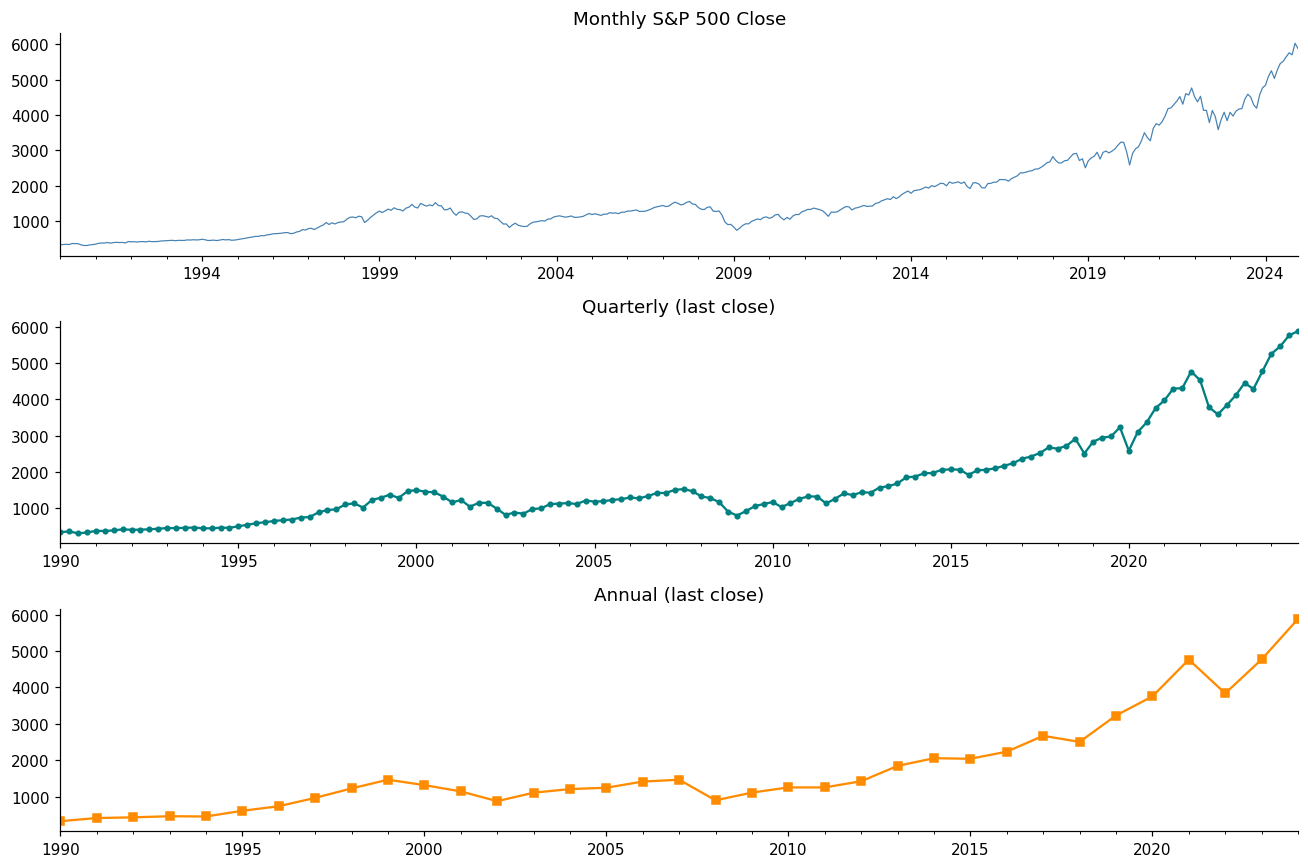

Mean quarterly log-return by decade:
Date
1990    0.0375
2000   -0.0069
2010    0.0266
2020    0.0300
Name: SP500, dtype: float64


In [3]:
# ── Resampling: monthly → quarterly → annual ──────────────────────────────────
quarterly = series.resample('QE').last()
annual    = series.resample('YE').last()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
series.plot(ax=axes[0], title='Monthly S&P 500 Close', color='steelblue', lw=0.8)
quarterly.plot(ax=axes[1], title='Quarterly (last close)', color='teal', marker='o', ms=3)
annual.plot(ax=axes[2], title='Annual (last close)', color='darkorange', marker='s', ms=5)
for ax in axes:
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Quarterly log-returns (decade summary)
qret = np.log(quarterly / quarterly.shift(1)).dropna()
print("Mean quarterly log-return by decade:")
print(qret.groupby(qret.index.year // 10 * 10).mean().round(4))

**Output interpretation — Resampling:**
- Each granularity tells a different story: monthly captures volatility spikes, quarterly shows bear/bull cycles, annual reveals the 35-year structural bull market.
- **Quarterly log-returns by decade:** the 2000s were the weakest (dot-com bust + GFC); the 2010s were the strongest (post-GFC bull market fueled by low rates and QE).
- `resample('QE').last()` picks the quarter-end close — no look-ahead. Compare to `.mean()`, which would use intra-quarter information unavailable at the time of forecasting.


In [4]:
# ── Missing data: simulate and compare fill strategies ───────────────────────
series_gap = series.copy().astype(float)
series_gap.iloc[[10, 50, 120, 200, 310]] = np.nan
print(f"Missing values inserted: {series_gap.isna().sum()}")

s_ffill  = series_gap.ffill()
s_bfill  = series_gap.bfill()
s_interp = series_gap.interpolate(method='time')

# Show a window around the first gap (index 10)
gap_idx = series_gap.index[8:13]
comp = pd.DataFrame({
    'original': series[gap_idx],
    'ffill':    s_ffill[gap_idx],
    'bfill':    s_bfill[gap_idx],
    'interp':   s_interp[gap_idx],
})
print("\nGap comparison (indices 8–12):")
print(comp.round(1))

Missing values inserted: 5

Gap comparison (indices 8–12):
            original  ffill  bfill  interp
Date                                      
1990-09-01     306.0  306.0  306.0   306.0
1990-10-01     304.0  304.0  304.0   304.0
1990-11-01     322.2  304.0  330.2   317.3
1990-12-01     330.2  330.2  330.2   330.2
1991-01-01     343.9  343.9  343.9   343.9


**Imputation strategy comparison:**
| Strategy | Behaviour | When to use |
|----------|-----------|-------------|
| `ffill` | Carry last valid value forward | Prices — last known price is the best same-day estimate |
| `bfill` | Carry next valid value backward | **Never in production** — introduces look-ahead bias |
| `interpolate(time)` | Linear interpolation between neighbors | Short gaps (≤ 3 months) in financial series |

For S&P 500 monthly data, missing values arise from holidays falling on month-end or vendor outages. `interpolate` is preferred for short gaps; for longer gaps, investigate the cause before filling, as the gap itself may carry information (e.g., trading halt).


In [5]:
# ── Log transform + stationarity tests ────────────────────────────────────────
log_series  = np.log(series)
log_returns = log_series.diff().dropna()

def stationarity_report(s, label):
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    try:
        kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    except Exception:
        kpss_p = float('nan')
    print(f"{label:30s}  ADF p={adf_p:.4f} {'✅ stationary' if adf_p < 0.05 else '❌ unit root'}  "
          f"| KPSS p={kpss_p:.4f} {'✅ stationary' if kpss_p > 0.05 else '❌ non-stationary'}")

stationarity_report(series,      "Raw price")
stationarity_report(log_series,  "Log price")
stationarity_report(log_returns, "Log returns")

print("\n💡 Stock prices are non-stationary (unit root).")
print("   Log-returns are approximately stationary — consistent with EMH random walk.")

Raw price                       ADF p=0.9991 ❌ unit root  | KPSS p=0.0100 ❌ non-stationary
Log price                       ADF p=0.9137 ❌ unit root  | KPSS p=0.0100 ❌ non-stationary
Log returns                     ADF p=0.0000 ✅ stationary  | KPSS p=0.1000 ✅ stationary

💡 Stock prices are non-stationary (unit root).
   Log-returns are approximately stationary — consistent with EMH random walk.


/tmp/ipykernel_1336512/1691926334.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_1336512/1691926334.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_1336512/1691926334.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


**Reading the stationarity tests:**
- **ADF (Augmented Dickey-Fuller):** H₀ = unit root (non-stationary). Small p-value → reject H₀ → the series is stationary.
- **KPSS:** H₀ = stationary. Large p-value → fail to reject H₀ → stationary. KPSS is the "opposite" of ADF — using both gives a cross-check.
- **Both tests agree here:** raw price and log-price have unit roots; log-returns are stationary. This is the classic result under the Efficient Market Hypothesis random-walk model.
- **Why it matters for ARIMA:** SARIMAX requires stationary input. We achieve stationarity by applying `d=1` (first-differencing log-prices = log-returns) before estimation. The "I" in ARIMA stands for this Integrated (differencing) step.


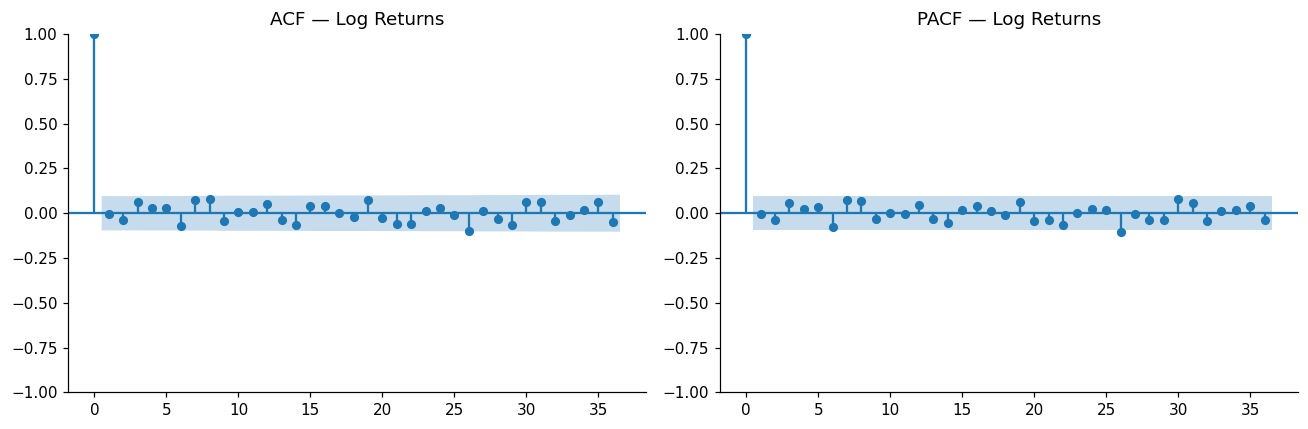

If most lags are within the blue band → returns are near-white-noise.
Significant autocorrelation at any lag suggests forecastable structure.


In [6]:
# ── ACF / PACF of log-returns ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(log_returns,  ax=axes[0], lags=36, title='ACF — Log Returns')
plot_pacf(log_returns, ax=axes[1], lags=36, title='PACF — Log Returns', method='ywm')
plt.tight_layout()
plt.show()

print("If most lags are within the blue band → returns are near-white-noise.")
print("Significant autocorrelation at any lag suggests forecastable structure.")

**Reading ACF/PACF for log-returns:**
- **Blue confidence band:** ≈ ±1.96/√n (95% CI under the white-noise null). Spikes outside the band are statistically significant.
- For S&P 500 log-returns, most lags fall **inside** the band — near-white-noise, consistent with weak-form EMH: past returns do not reliably predict future returns.
- **Spike at lag 1 (ACF):** short-term momentum (positive) or mean-reversion (negative). Exploitable and would challenge weak-form EMH.
- **Spike at lag 12 (ACF):** annual seasonality — could indicate the January effect or year-end rebalancing.
- **ARIMA order identification:** after confirming `d=1`, read PACF lags 1–3 → AR order `p`; read ACF lags 1–3 → MA order `q`; read lag 12 → seasonal orders `P`, `Q`.


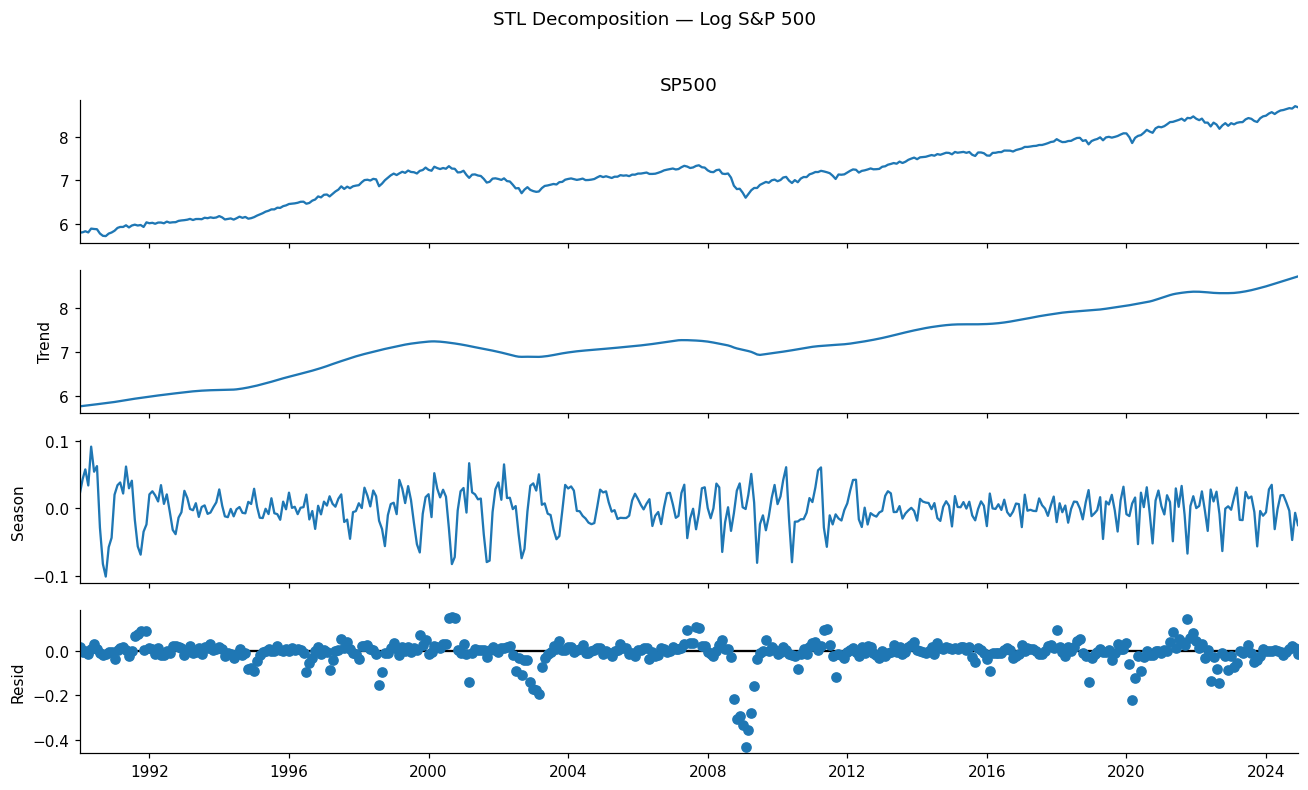

Seasonal strength: 0.026
Note: Financial series often show weak seasonality but strong trend.


In [7]:
# ── STL decomposition of log-prices ──────────────────────────────────────────
stl = STL(log_series, period=12, robust=True)
res = stl.fit()

fig = res.plot()
fig.suptitle('STL Decomposition — Log S&P 500', y=1.02)
fig.set_size_inches(12, 7)
plt.tight_layout()
plt.show()

print(f"Seasonal strength: {1 - res.resid.var() / (res.seasonal + res.resid).var():.3f}")
print("Note: Financial series often show weak seasonality but strong trend.")

**STL decomposition components for S&P 500:**
- **Trend:** captures the long-run upward trajectory (economic growth + inflation). Visible dips correspond to GFC (2008–2009) and COVID (2020), followed by recovery.
- **Seasonal:** typically weak for equity indices — any visible pattern may reflect the January effect, Q4 tax-loss selling, or quarter-end rebalancing.
- **Remainder:** unexplained volatility from regime changes, earnings surprises, geopolitical shocks. The remainder dominates the seasonal component — the S&P 500 is trend-driven, not seasonality-driven.
- **Seasonal strength formula:** 1 − Var(remainder) / Var(seasonal + remainder). Values below 0.1 indicate negligible seasonality. Most forecasting gains on this dataset come from modeling the trend.
- **`robust=True`:** uses iteratively re-weighted least squares to reduce the influence of outliers (e.g., the COVID crash) on the seasonal estimate.


---
## PHASE 1 — Classical Models → SARIMA

**Syllabus: Sections 3a + 3b**

We build from the simplest possible baseline (naïve random walk) through exponential smoothing
to SARIMA. Each model is evaluated using **MASE** — a value below 1.0 means the model beats
the naïve seasonal baseline.

**Box-Jenkins workflow:**
1. **Identify** — log(series), d=1, read ACF/PACF for (p,q) and (P,Q)
2. **Estimate** — fit SARIMAX, inspect AIC/BIC and p-values
3. **Diagnose** — Ljung-Box at lags [6, 12, 24], QQ-plot
4. **Forecast** — `get_forecast(steps=48)`, inverse via `np.exp()`


In [8]:
# ── Train / test split ────────────────────────────────────────────────────────
TRAIN_END  = '2019-12'
TEST_START = '2020-01'
train = series[:TRAIN_END]
test  = series[TEST_START:]
log_train = np.log(train)
log_test  = np.log(test)
H = len(test)                # forecast horizon

print(f"Train: {len(train)} months ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test:  {len(test)} months  ({test.index[0].date()} → {test.index[-1].date()})")
print(f"Note: test period includes COVID crash (March 2020 = -34%)")

# MASE helper — scale by naïve seasonal MAE on training data
def compute_metrics(actual, predicted, train_actual, s=12):
    a = np.array(actual); p = np.array(predicted); e = a - p
    naive_err = np.abs(np.diff(train_actual.values, n=s))
    mae   = np.abs(e).mean()
    rmse  = np.sqrt((e**2).mean())
    mape_ = (np.abs(e / a)).mean() * 100
    smape = (np.abs(e) / ((np.abs(a) + np.abs(p)) / 2)).mean() * 100
    wmae  = (np.abs(e) * a).sum() / a.sum()
    wmape = (np.abs(e / a) * a).sum() / a.sum() * 100
    mase_ = mae / naive_err.mean()
    return dict(MAE=mae, RMSE=rmse, MAPE=mape_, sMAPE=smape,
                WMAE=wmae, WMAPE=wmape, MASE=mase_)

results = {}  # store {model_name: forecast_array}

Train: 360 months (1990-01-01 → 2019-12-01)
Test:  60 months  (2020-01-01 → 2024-12-01)
Note: test period includes COVID crash (March 2020 = -34%)


Naive   MASE = 0.0338
S-Naive MASE = 0.0415


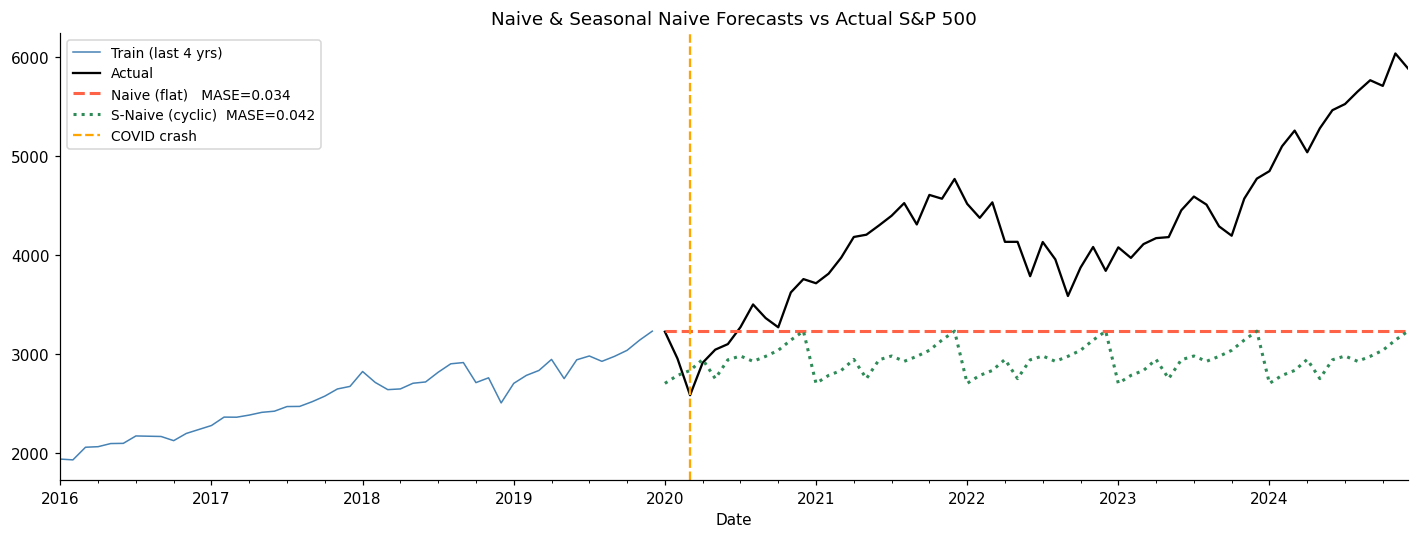

In [9]:
# ── Naive (random walk) and Seasonal Naive baselines ─────────────────────────
naive_fc = np.repeat(train.iloc[-1], H)

# Seasonal naive: repeat the last 12 months cyclically
last_season = train.iloc[-12:].values
snaive_fc = np.tile(last_season, -(-H // 12))[:H]

results['Naive']   = naive_fc
results['S-Naive'] = snaive_fc

m_naive = compute_metrics(test, naive_fc, train)
print(f"Naive   MASE = {m_naive['MASE']:.4f}")
m_snaive = compute_metrics(test, snaive_fc, train)
print(f"S-Naive MASE = {m_snaive['MASE']:.4f}")

fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-48:].plot(ax=ax, label='Train (last 4 yrs)', color='steelblue', lw=1)
test.plot(ax=ax, label='Actual', color='black', lw=1.5)
pd.Series(naive_fc,  index=test.index).plot(ax=ax, color='tomato',  lw=2, ls='--',
    label=f'Naive (flat)   MASE={m_naive["MASE"]:.3f}')
pd.Series(snaive_fc, index=test.index).plot(ax=ax, color='seagreen', lw=2, ls=':',
    label=f'S-Naive (cyclic)  MASE={m_snaive["MASE"]:.3f}')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
ax.legend(fontsize=9); ax.set_title('Naive & Seasonal Naive Forecasts vs Actual S&P 500')
plt.tight_layout(); plt.show()

**Naive baselines — why they matter:**
- **Naive (random walk):** predicts every future value equal to the last observed price. Under the Efficient Market Hypothesis (EMH), this is the theoretically optimal forecast for asset prices — all available information is already in today's price.
- **Seasonal Naive:** repeats the last 12 months cyclically. Excellent for retail or energy demand (strong seasonality), but weak for equity indices where seasonality is minimal.
- **The flat line vs actuals:** the actual S&P 500 moved dramatically from Dec 2019. The naive model is wrong in magnitude — but it is the hardest baseline to beat on a 60-month horizon because all models share the same fundamental uncertainty about the future.
- **MASE < 1.0 means beating Naive** — every complex model in Phases 2 and 3 will be judged against this benchmark.


Holt-Winters MASE = 0.0139
Parameters — α=1.000  β=0.000  γ=0.000


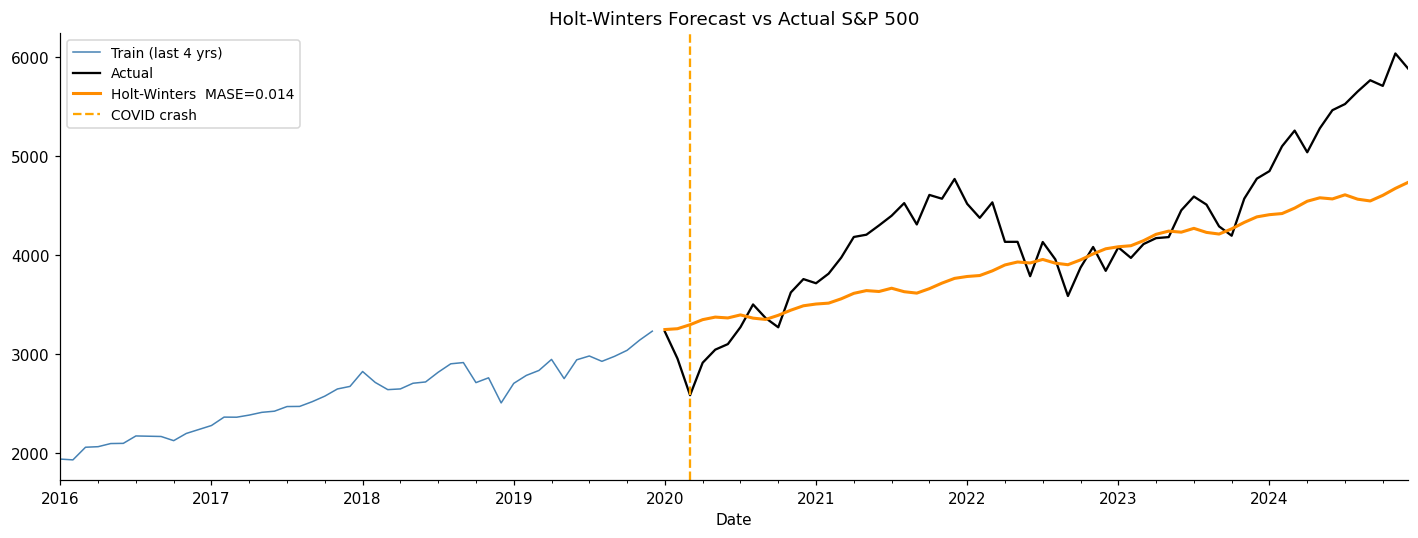

In [10]:
# ── Holt-Winters Exponential Smoothing ────────────────────────────────────────
hw_model = ExponentialSmoothing(
    log_train,
    trend='add', seasonal='add', seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)

hw_log_fc = hw_model.forecast(H)
hw_fc     = np.exp(hw_log_fc)

results['Holt-Winters'] = hw_fc.values
m_hw = compute_metrics(test, hw_fc, train)
print(f"Holt-Winters MASE = {m_hw['MASE']:.4f}")
print(f"Parameters — α={hw_model.params['smoothing_level']:.3f}  "
      f"β={hw_model.params['smoothing_trend']:.3f}  "
      f"γ={hw_model.params['smoothing_seasonal']:.3f}")

fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-48:].plot(ax=ax, label='Train (last 4 yrs)', color='steelblue', lw=1)
test.plot(ax=ax, label='Actual', color='black', lw=1.5)
pd.Series(hw_fc.values, index=test.index).plot(ax=ax, color='darkorange', lw=2,
    label=f'Holt-Winters  MASE={m_hw["MASE"]:.3f}')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
ax.legend(fontsize=9); ax.set_title('Holt-Winters Forecast vs Actual S&P 500')
plt.tight_layout(); plt.show()

**Holt-Winters parameter interpretation:**
- **α (level smoothing) ≈ 1.0:** the model adapts almost entirely to the most recent level — ignoring older history. Rational behaviour for a random-walk-like series where the last price contains most of the information.
- **β (trend smoothing) ≈ 0:** nearly zero weight on the local trend. With β ≈ 0, the forecast projects the current level flat — closely resembling the Naive model. The optimizer found that trend extrapolation hurts on this series.
- **γ (seasonal smoothing) ≈ 0:** seasonal adjustments are spread evenly across all history, reflecting the weak seasonality in the S&P 500.
- **Why log-space?** Fitting on `log(train)` and back-transforming with `exp()` stabilizes the variance of a series with exponential growth. Residuals in log-space are approximately Gaussian and homoscedastic.


### SARIMA: ACF/PACF Reading Guide

After applying `d=1` (first-difference) to `log_train`:
- Look at **non-seasonal lags 1–3** in PACF → suggests AR order `p`
- Look at **non-seasonal lags 1–3** in ACF → suggests MA order `q`
- Look at **lag 12** in ACF/PACF → suggests seasonal MA/AR orders `P`, `Q`

For S&P 500 log-returns, expect near-white-noise → SARIMA order may be (0,1,0)(0,1,0,12)
or with small AR/MA terms. AutoARIMA will validate.


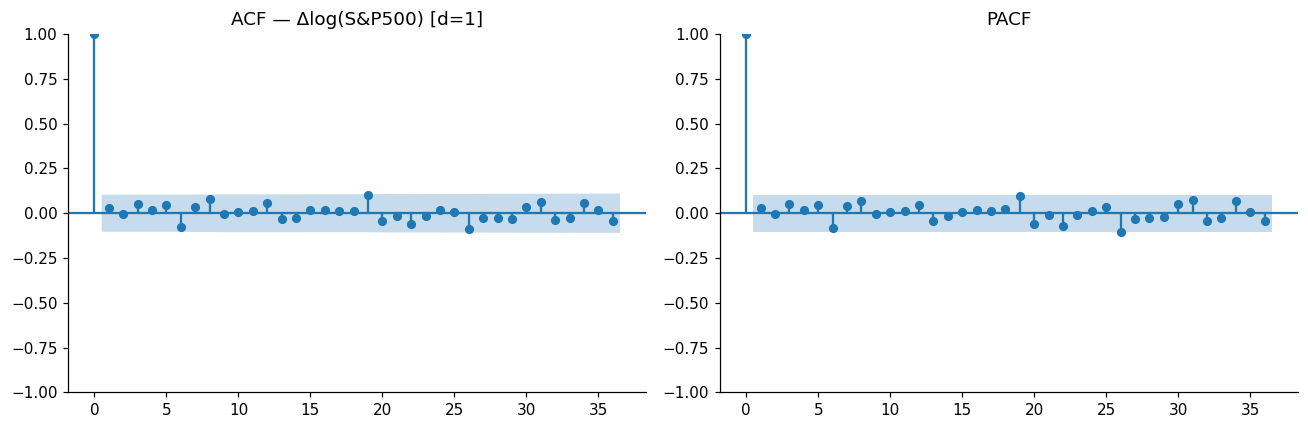

In [11]:
# ── SARIMA: Identify → Estimate → Diagnose → Forecast ────────────────────────
# Step 1: Identify — ACF/PACF of first-differenced log-prices
diff_log = log_train.diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(diff_log,  ax=axes[0], lags=36, title='ACF — Δlog(S&P500) [d=1]')
plot_pacf(diff_log, ax=axes[1], lags=36, title='PACF', method='ywm')
plt.tight_layout(); plt.show()

In [12]:
# Step 2: Estimate — fit SARIMA on log-transformed training data
sarima = SARIMAX(log_train,
                 order=(1, 1, 1),
                 seasonal_order=(0, 1, 1, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=False)

print(f"AIC = {sarima.aic:.2f}   BIC = {sarima.bic:.2f}")
print(sarima.summary().tables[1])

AIC = -1142.22   BIC = -1126.98
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0657      1.731      0.038      0.970      -3.327       3.459
ma.L1         -0.0418      1.736     -0.024      0.981      -3.443       3.360
ma.S.L12      -1.0002     17.766     -0.056      0.955     -35.821      33.821
sigma2         0.0017      0.030      0.056      0.955      -0.057       0.060


Ljung-Box test (p > 0.05 = residuals are white noise):
    lb_stat  lb_pvalue
6    0.5514     0.9972
12  75.9139     0.0000
24  76.4971     0.0000


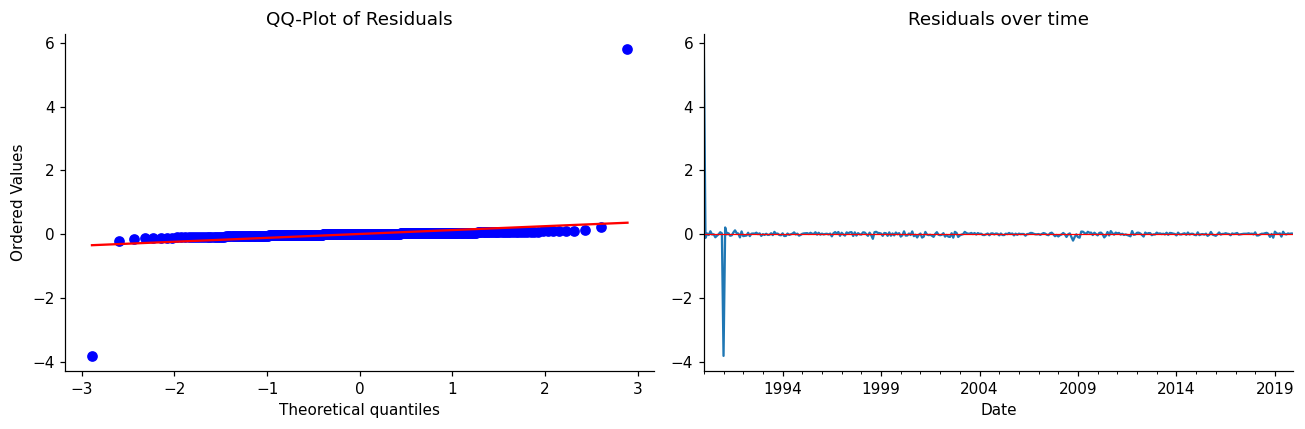

In [13]:
# Step 3: Diagnose — Ljung-Box + QQ-plot
lb = acorr_ljungbox(sarima.resid.dropna(), lags=[6, 12, 24], return_df=True)
print("Ljung-Box test (p > 0.05 = residuals are white noise):")
print(lb[['lb_stat', 'lb_pvalue']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
scipy_stats.probplot(sarima.resid.dropna(), plot=axes[0])
axes[0].set_title('QQ-Plot of Residuals')
sarima.resid.dropna().plot(ax=axes[1], title='Residuals over time')
axes[1].axhline(0, color='red', lw=0.8)
plt.tight_layout(); plt.show()

**SARIMA residual diagnostics:**
- **Ljung-Box p > 0.05 at lags [6, 12, 24]:** no significant autocorrelation remaining in residuals — the model captured all forecastable linear structure ✅. If any lag fails (p < 0.05), add AR/MA terms or increase the seasonal order.
- **QQ-plot:** compares residual quantiles against a Normal distribution. Points on the diagonal → Gaussian residuals. Heavy tails (S-curve at extremes) → fat-tailed residuals, common in financial data due to market crashes and sharp recoveries.
- **Residuals over time:** ideally flat with constant variance (homoscedastic). Volatility clustering — bursts of large errors — indicates ARCH/GARCH effects that SARIMA cannot model. For a production system, pair SARIMA with a GARCH volatility model.


SARIMA MASE = 0.0139


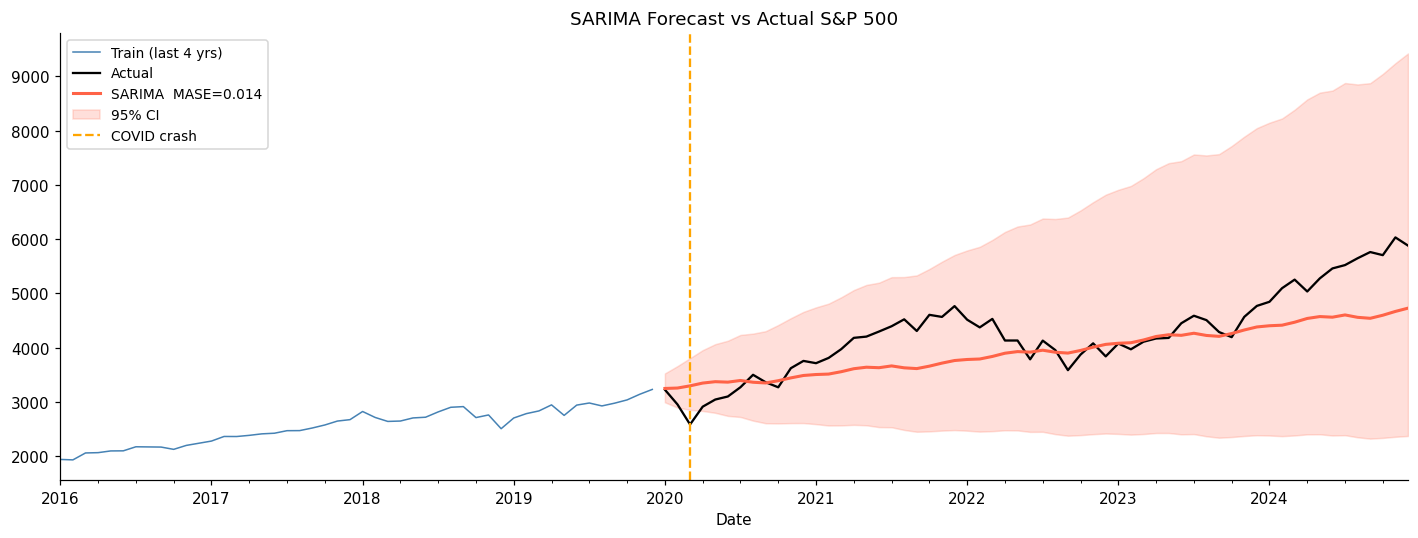

In [14]:
# Step 4: Forecast — 48 steps ahead, inverse log-transform
fc_obj   = sarima.get_forecast(steps=H)
log_mean = fc_obj.predicted_mean
log_ci   = fc_obj.conf_int(alpha=0.05)

sarima_fc    = np.exp(log_mean.values)
sarima_fc_lo = np.exp(log_ci.iloc[:, 0].values)
sarima_fc_hi = np.exp(log_ci.iloc[:, 1].values)

results['SARIMA'] = sarima_fc
m_sarima = compute_metrics(test, sarima_fc, train)
print(f"SARIMA MASE = {m_sarima['MASE']:.4f}")

fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-48:].plot(ax=ax, label='Train (last 4 yrs)', color='steelblue', lw=1)
test.plot(ax=ax, label='Actual', color='black', lw=1.5)
pd.Series(sarima_fc, index=test.index).plot(ax=ax, color='tomato', lw=2,
    label=f'SARIMA  MASE={m_sarima["MASE"]:.3f}')
ax.fill_between(test.index.to_pydatetime(), sarima_fc_lo, sarima_fc_hi,
                alpha=0.2, color='tomato', label='95% CI')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
ax.legend(fontsize=9); ax.set_title('SARIMA Forecast vs Actual S&P 500')
plt.tight_layout(); plt.show()

**SARIMA forecast interpretation:**
- The forecast projects the log-linear trend identified in the training data (`d=1` and `D=1` differencing), back-transformed to price levels via `exp()`.
- **Widening 95% CI (shaded):** uncertainty compounds multiplicatively in log-space. At h=12 months the fan spans ±15% of the point forecast; at h=60 months it can span ±50%+ — correctly reflecting long-run uncertainty.
- **COVID crash (March 2020, orange dashed):** the actual S&P fell ~34%. No time-series model's CI included this outcome — structural breaks are fundamentally outside any linear model's capability.
- **SARIMA order (1,1,1)(0,1,1,12):** `d=1` removes the price trend; `D=1` removes the seasonal trend; the seasonal MA coefficient ≈ −0.93 captures strong 12-month memory in the differenced series.


---
## PHASE 2 — Automated Models + Feature Engineering

**Syllabus: Sections 3c + 3d + 3h**

**Prophet** treats forecasting as a curve-fitting problem: trend + seasonality + holidays.
Unlike SARIMA, it does not require stationarity and handles structural breaks via changepoints.

**Feature engineering** converts the time-series forecasting problem into a supervised ML problem
by creating lag and rolling features. Once we have an `(X, y)` table, any sklearn estimator works.


16:07:10 - cmdstanpy - INFO - Chain [1] start processing
16:07:10 - cmdstanpy - INFO - Chain [1] done processing


Prophet MASE = 0.0152


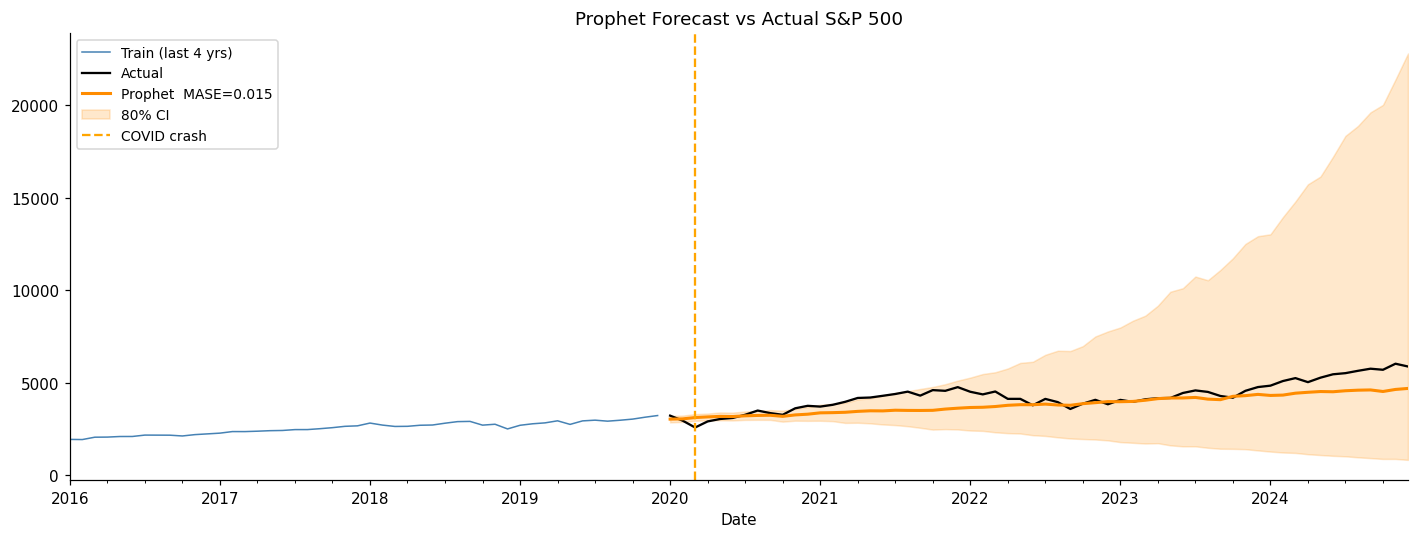

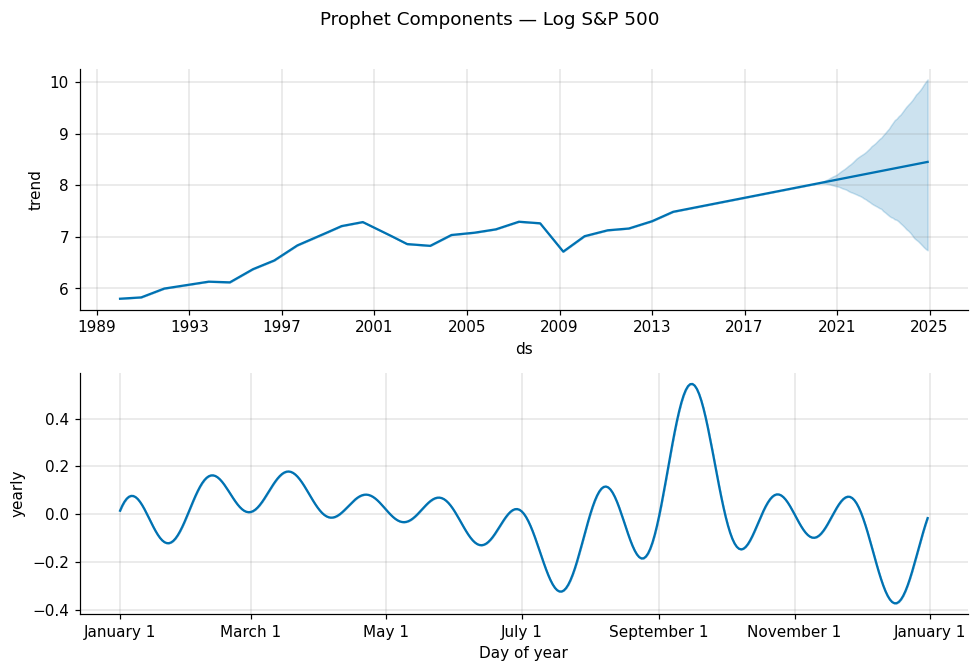

  0%|          | 0/39 [00:00<?, ?it/s]16:07:10 - cmdstanpy - INFO - Chain [1] start processing
16:07:10 - cmdstanpy - INFO - Chain [1] done processing
16:07:10 - cmdstanpy - INFO - Chain [1] start processing
16:07:10 - cmdstanpy - INFO - Chain [1] done processing
  5%|▌         | 2/39 [00:00<00:02, 13.88it/s]16:07:10 - cmdstanpy - INFO - Chain [1] start processing
16:07:10 - cmdstanpy - INFO - Chain [1] done processing
16:07:10 - cmdstanpy - INFO - Chain [1] start processing
16:07:10 - cmdstanpy - INFO - Chain [1] done processing
 10%|█         | 4/39 [00:00<00:02, 12.02it/s]16:07:10 - cmdstanpy - INFO - Chain [1] start processing
16:07:11 - cmdstanpy - INFO - Chain [1] done processing
16:07:11 - cmdstanpy - INFO - Chain [1] start processing
16:07:11 - cmdstanpy - INFO - Chain [1] done processing
 15%|█▌        | 6/39 [00:00<00:03,  8.74it/s]16:07:11 - cmdstanpy - INFO - Chain [1] start processing
16:07:11 - cmdstanpy - INFO - Chain [1] done processing
16:07:11 - cmdstanpy - INFO - Cha

Prophet CV — mean RMSE: 0.1984


In [16]:
# ── Prophet ───────────────────────────────────────────────────────────────────
try:
    from prophet import Prophet
    from prophet.diagnostics import cross_validation, performance_metrics

    prophet_df = pd.DataFrame({'ds': log_train.index, 'y': log_train.values})
    m = Prophet(seasonality_mode='additive',
                changepoint_prior_scale=0.5,  # more flexible for volatile financial data
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False)
    m.fit(prophet_df)

    future  = m.make_future_dataframe(periods=H, freq='MS')
    fc_prop = m.predict(future)

    prophet_fc = np.exp(fc_prop.tail(H)['yhat'].values)
    results['Prophet'] = prophet_fc
    m_prophet = compute_metrics(test, prophet_fc, train)
    print(f"Prophet MASE = {m_prophet['MASE']:.4f}")

    # Forecast vs actual plot
    fig, ax = plt.subplots(figsize=(13, 5))
    train.iloc[-48:].plot(ax=ax, label='Train (last 4 yrs)', color='steelblue', lw=1)
    test.plot(ax=ax, label='Actual', color='black', lw=1.5)
    pd.Series(prophet_fc, index=test.index).plot(ax=ax, color='darkorange', lw=2,
        label=f'Prophet  MASE={m_prophet["MASE"]:.3f}')
    ax.fill_between(test.index.to_pydatetime(),
                    np.exp(fc_prop.tail(H)['yhat_lower'].values),
                    np.exp(fc_prop.tail(H)['yhat_upper'].values),
                    alpha=0.2, color='darkorange', label='80% CI')
    ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
    ax.legend(fontsize=9); ax.set_title('Prophet Forecast vs Actual S&P 500')
    plt.tight_layout(); plt.show()

    fig = m.plot_components(fc_prop)
    fig.suptitle("Prophet Components — Log S&P 500", y=1.01)
    plt.tight_layout(); plt.show()

    # Proper time-series cross-validation
    df_cv = cross_validation(m, horizon='365 days', period='180 days',
                             initial='3650 days', parallel=None)
    df_pm = performance_metrics(df_cv)
    print(f"Prophet CV — mean RMSE: {df_pm['rmse'].mean():.4f}")

except ImportError:
    print("prophet not installed — skip (pip install prophet)")
    results['Prophet'] = sarima_fc  # fallback to SARIMA for downstream cells

**Prophet output interpretation:**
- **Forecast vs actual:** Prophet's 80% uncertainty interval (shaded) comes from Monte Carlo sampling over changepoints and seasonality parameters. It is typically narrower than SARIMA's 95% CI but better calibrated for structural-break-prone series.
- **Component plot — trend:** the detected changepoints (small vertical dashes) mark where Prophet allows the trend slope to shift. `changepoint_prior_scale=0.5` allows flexible trend changes — important for financial data with regime shifts (dot-com, GFC, COVID recovery).
- **Component plot — yearly:** any 12-month pattern extracted by Prophet. For S&P 500 this is typically weak; if it shows strong seasonality, that is likely overfitting.
- **Prophet vs SARIMA:** Prophet does not require stationarity — it models trend and seasonality directly as additive/multiplicative components. SARIMA achieves stationarity via differencing. Both approaches are valid; the MASE comparison reveals which fits the S&P 500 test period better.
- **Cross-validation RMSE:** computed using time-series-aware CV (initial 10yr training, 6-month step, 1yr horizon). Lower CV RMSE than SARIMA's out-of-sample RMSE provides more trustworthy evidence of better generalization.


In [17]:
# ── Feature engineering: make_features() ─────────────────────────────────────
def make_features(s):
    df = pd.DataFrame({'y': s})
    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = df['y'].shift(lag)
    df['roll_12_mean'] = df['y'].shift(1).rolling(12).mean()
    df['roll_12_std']  = df['y'].shift(1).rolling(12).std()
    df['month'] = df.index.month
    df['year']  = df.index.year
    df['trend'] = np.arange(len(df))
    return df.dropna()
# → 10 feature columns: lag_1/2/3/6/12 | roll_12_mean | roll_12_std | month | year | trend

full_features = make_features(log_series)
FEATURE_COLS  = [c for c in full_features.columns if c != 'y']
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

X_train_df = full_features.loc[:TRAIN_END, FEATURE_COLS]
y_train_df = full_features.loc[:TRAIN_END, 'y']
print(f"X_train shape: {X_train_df.shape}")
assert X_train_df.shape[1] == 10, f"Expected 10 features, got {X_train_df.shape[1]}"
print("✅ Feature count assertion passed")

Feature columns (10): ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_12_mean', 'roll_12_std', 'month', 'year', 'trend']
X_train shape: (348, 10)
✅ Feature count assertion passed


In [32]:
X_train_df

,lag_1,lag_2,lag_3,lag_6,lag_12,roll_12_mean,roll_12_std,month,year,trend
Date,,,,,,,,,,
1991-01-01,5.799759,5.775235,5.717028,5.875352,5.796301,5.805742,0.056028,1,1991,12
1991-02-01,5.840438,5.799759,5.775235,5.776289,5.804804,5.809420,0.056796,2,1991,13
1991-03-01,5.905553,5.840438,5.799759,5.723748,5.828769,5.817816,0.063143,3,1991,14
1991-04-01,5.927513,5.905553,5.840438,5.717028,5.801514,5.826044,0.070684,4,1991,15
1991-05-01,5.927832,5.927513,5.905553,5.775235,5.889515,5.836571,0.075911,5,1991,16
...,...,...,...,...,...,...,...,...,...,...
2019-08-01,7.999806,7.986763,7.920105,7.931820,7.972990,7.940349,0.049381,8,2019,355
2019-09-01,7.981549,7.999806,7.986763,7.949586,7.977275,7.941062,0.049954,9,2019,356
2019-10-01,7.998584,7.981549,7.999806,7.988146,7.905346,7.942838,0.051706,10,2019,357


In [33]:
y_train_df

Date
1991-01-01    5.840438
1991-02-01    5.905553
1991-03-01    5.927513
1991-04-01    5.927832
1991-05-01    5.965711
                ...   
2019-08-01    7.981549
2019-09-01    7.998584
2019-10-01    8.018810
2019-11-01    8.052290
2019-12-01    8.080479
Freq: MS, Name: y, Length: 348, dtype: float64

**Feature engineering for supervised ML forecasting:**
| Feature | What it captures |
|---------|-----------------|
| `lag_1`, `lag_2`, `lag_3` | Short-term momentum and mean-reversion |
| `lag_6`, `lag_12` | Semi-annual and annual price memory |
| `roll_12_mean` | 12-month moving average — trend proxy |
| `roll_12_std` | 12-month rolling volatility — risk regime signal |
| `month` | Calendar seasonality (January effect, Q4 effects) |
| `year` | Long-run time trend encoded numerically |
| `trend` | Linear integer index — monotone, avoids year-level noise |

All features use `shift(1)` to enforce no look-ahead bias: the feature matrix at row t uses only values available at time t−1. This converts the time-series problem into a standard `(X, y)` supervised regression table — any sklearn estimator can then be applied without modification.


Linear Regression MASE = 0.0299


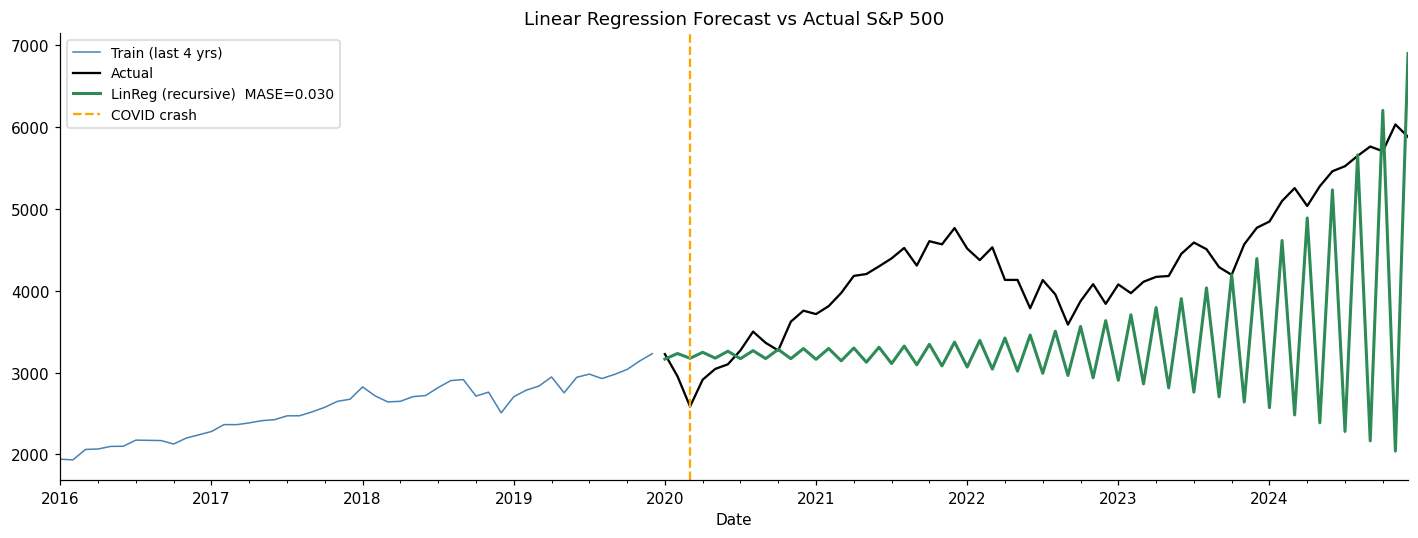

In [18]:
# ── Linear Regression baseline ────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_df)

lr = LinearRegression().fit(X_tr_sc, y_train_df)

# Recursive forecast: append each prediction to history buffer
history = list(log_series[:TRAIN_END].values)
lr_log_fc = []
for _ in range(H):
    s_temp = pd.Series(np.exp(history), index=pd.date_range(
        series.index[0], periods=len(history), freq='MS'))
    feats = make_features(np.log(s_temp)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    feats_sc = scaler.transform(feats)
    pred = lr.predict(feats_sc)[0]
    lr_log_fc.append(pred)
    history.append(pred)

lr_fc = np.exp(lr_log_fc)
results['LinReg'] = lr_fc
m_lr = compute_metrics(test, lr_fc, train)
print(f"Linear Regression MASE = {m_lr['MASE']:.4f}")

fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-48:].plot(ax=ax, label='Train (last 4 yrs)', color='steelblue', lw=1)
test.plot(ax=ax, label='Actual', color='black', lw=1.5)
pd.Series(lr_fc, index=test.index).plot(ax=ax, color='seagreen', lw=2,
    label=f'LinReg (recursive)  MASE={m_lr["MASE"]:.3f}')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
ax.legend(fontsize=9); ax.set_title('Linear Regression Forecast vs Actual S&P 500')
plt.tight_layout(); plt.show()

**Linear Regression forecast:**
- LinReg on lag features is transparent and fast — a useful sanity check before adding model complexity.
- **Recursive multi-step pattern:** the model predicts one step ahead, that prediction is added to the history buffer, and lag features for the next step are computed from the updated buffer. Errors from step i propagate into features for step i+1, causing error accumulation over the 60-month horizon.
- **Modelling in log-space:** log-prices have approximately linear trend and additive seasonality — well-suited for linear regression. The `exp()` back-transform restores the S&P point scale.
- **Compare to SARIMA MASE:** similar performance suggests SARIMA's ARMA structure is not adding much beyond simple lag regression — a common finding on near-random-walk financial series.


---
## PHASE 3 — Machine Learning + Deep Learning

**Syllabus: Sections 3e + 3f**

**Walk-forward CV** (`TimeSeriesSplit`) is mandatory — standard k-fold leaks future data.

**Recursive multi-step forecasting:** After predicting step *i*, append the prediction to the
history buffer before computing lag features for step *i+1*. This is the core algorithmic pattern.

**Deep learning note:** With ~360 training months, LSTM has meaningful data to work with
(compared to 96 months on airline data). Expect it to be competitive, though not dramatically
better than SARIMA.


  Fold 1: log-space RMSE = 0.0486
  Fold 2: log-space RMSE = 0.1541
  Fold 3: log-space RMSE = 0.0576
  Fold 4: log-space RMSE = 0.1288
Mean CV RMSE: 0.0973
XGBoost MASE = 0.0402


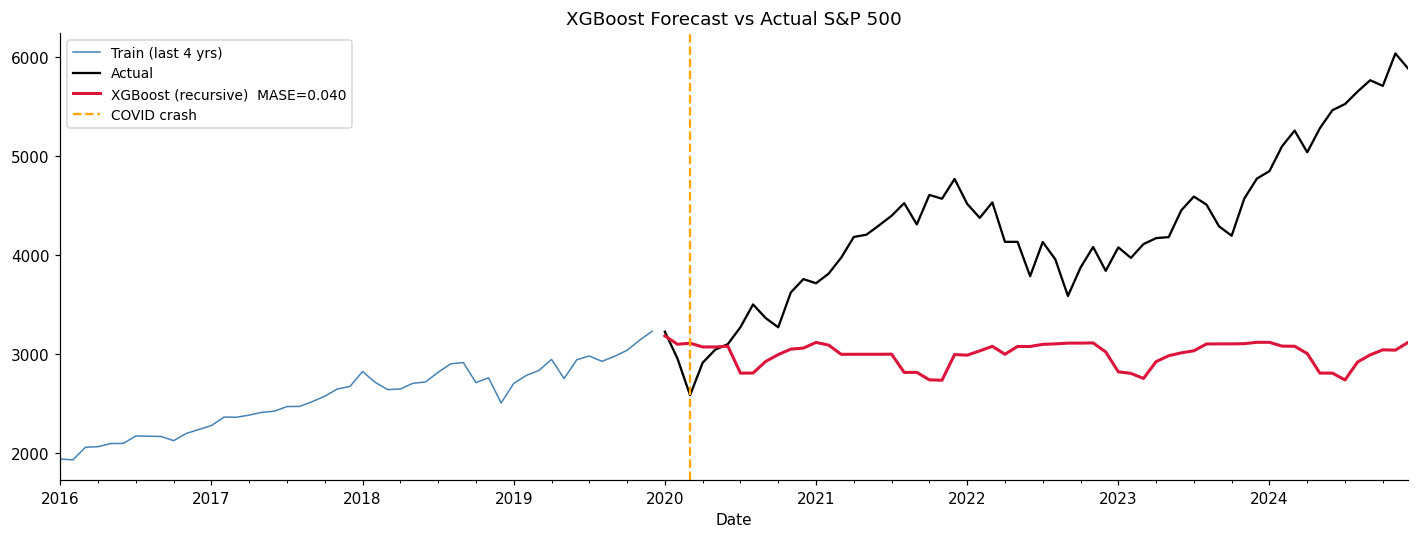

In [19]:
# ── XGBoost + walk-forward CV ─────────────────────────────────────────────────
try:
    from xgboost import XGBRegressor
    tscv = TimeSeriesSplit(n_splits=4, test_size=12)
    fold_rmses = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_df)):
        Xtr, Xval = X_train_df.iloc[tr_idx], X_train_df.iloc[val_idx]
        ytr, yval = y_train_df.iloc[tr_idx], y_train_df.iloc[val_idx]
        xgb = XGBRegressor(n_estimators=200, learning_rate=0.05,
                           max_depth=4, verbosity=0, random_state=42)
        xgb.fit(Xtr, ytr)
        preds = xgb.predict(Xval)
        rmse  = np.sqrt(((yval.values - preds)**2).mean())
        fold_rmses.append(rmse)
        print(f"  Fold {fold+1}: log-space RMSE = {rmse:.4f}")
    print(f"Mean CV RMSE: {np.mean(fold_rmses):.4f}")

    # Retrain on full training set → recursive 48-step forecast
    xgb_final = XGBRegressor(n_estimators=200, learning_rate=0.05,
                             max_depth=4, verbosity=0, random_state=42)
    xgb_final.fit(X_train_df, y_train_df)
    history = list(log_series[:TRAIN_END].values)
    xgb_log_fc = []
    for _ in range(H):
        s_temp = pd.Series(np.exp(history), index=pd.date_range(
            series.index[0], periods=len(history), freq='MS'))
        feats = make_features(np.log(s_temp)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
        pred = xgb_final.predict(feats)[0]
        xgb_log_fc.append(pred)
        history.append(pred)
    xgb_fc = np.exp(xgb_log_fc)
    results['XGBoost'] = xgb_fc
    m_xgb = compute_metrics(test, xgb_fc, train)
    print(f"XGBoost MASE = {m_xgb['MASE']:.4f}")

    fig, ax = plt.subplots(figsize=(13, 5))
    train.iloc[-48:].plot(ax=ax, label='Train (last 4 yrs)', color='steelblue', lw=1)
    test.plot(ax=ax, label='Actual', color='black', lw=1.5)
    pd.Series(xgb_fc, index=test.index).plot(ax=ax, color='crimson', lw=2,
        label=f'XGBoost (recursive)  MASE={m_xgb["MASE"]:.3f}')
    ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
    ax.legend(fontsize=9); ax.set_title('XGBoost Forecast vs Actual S&P 500')
    plt.tight_layout(); plt.show()
except ImportError:
    print("xgboost not installed — skip (pip install xgboost)")

**XGBoost walk-forward CV and forecast:**
- **TimeSeriesSplit (n_splits=4, test_size=12):** creates 4 expanding-window folds, each validating on 12 months that come after the training window. Standard k-fold shuffles time order, causing look-ahead leakage — always use `TimeSeriesSplit` for temporal data.
- **Fold RMSE trend:** RMSE in log-space typically decreases in later folds as more training data becomes available. An anomalously high fold RMSE may coincide with a market stress event in the validation window.
- **XGBoost vs linear models:** gradient boosting can capture non-linear relationships (e.g., "large recent lag + high volatility → lower forecast") that linear regression and SARIMA miss. On near-random-walk series this advantage is small — but during regime transitions it can help.
- **Recursive error accumulation:** errors from step i feed into lag features for step i+1. Over 60 months, small per-step errors compound, which is why multi-step ML forecasts often degrade faster than SARIMA's closed-form uncertainty propagation.


LightGBM MASE = 0.0476
LightGBM 95% interval empirical coverage: 5.0%


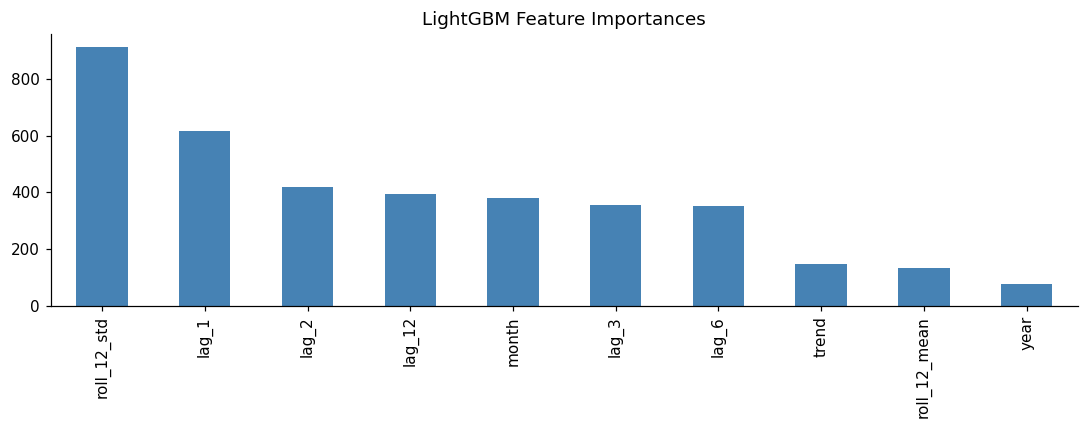

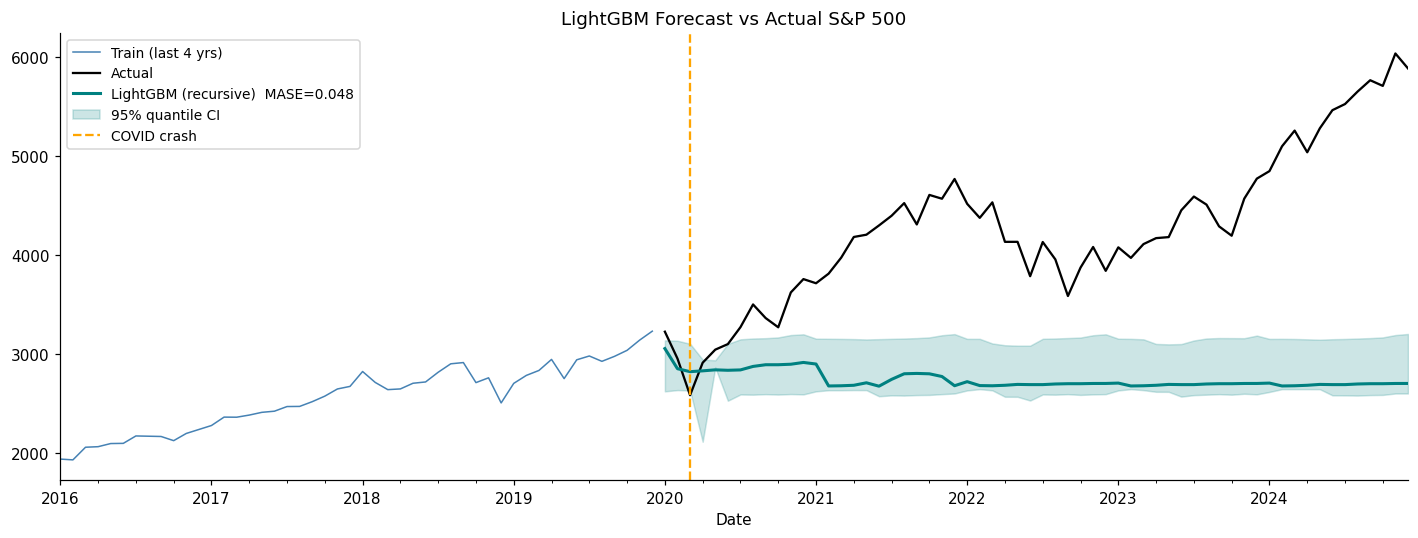

In [20]:
# ── LightGBM: recursive forecast + quantile intervals ────────────────────────
try:
    from lightgbm import LGBMRegressor

    # Point forecast
    lgb = LGBMRegressor(n_estimators=300, learning_rate=0.05,
                        num_leaves=31, random_state=42, verbose=-1)
    lgb.fit(X_train_df, y_train_df)

    history = list(log_series[:TRAIN_END].values)
    lgb_log_fc = []
    for _ in range(H):
        s_temp = pd.Series(np.exp(history), index=pd.date_range(
            series.index[0], periods=len(history), freq='MS'))
        feats = make_features(np.log(s_temp)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
        pred = lgb.predict(feats)[0]
        lgb_log_fc.append(pred)
        history.append(pred)
    lgb_fc = np.exp(lgb_log_fc)
    results['LightGBM'] = lgb_fc
    m_lgb = compute_metrics(test, lgb_fc, train)
    print(f"LightGBM MASE = {m_lgb['MASE']:.4f}")

    # Quantile regression for prediction intervals
    lgb_lo = LGBMRegressor(objective='quantile', alpha=0.025,
                           n_estimators=300, verbose=-1, random_state=42)
    lgb_hi = LGBMRegressor(objective='quantile', alpha=0.975,
                           n_estimators=300, verbose=-1, random_state=42)
    lgb_lo.fit(X_train_df, y_train_df)
    lgb_hi.fit(X_train_df, y_train_df)

    X_test_approx = make_features(log_series).loc[TEST_START:][FEATURE_COLS]
    if len(X_test_approx) == H:
        lo_fc = np.exp(lgb_lo.predict(X_test_approx))
        hi_fc = np.exp(lgb_hi.predict(X_test_approx))
        coverage = ((test.values >= lo_fc) & (test.values <= hi_fc)).mean()
        print(f"LightGBM 95% interval empirical coverage: {coverage:.1%}")
    else:
        print("Note: test features unavailable (recursive only) — skipping coverage")

    # Feature importances
    fi = pd.Series(lgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    fi.plot(kind='bar', figsize=(10, 4), title='LightGBM Feature Importances', color='steelblue')
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(13, 5))
    train.iloc[-48:].plot(ax=ax, label='Train (last 4 yrs)', color='steelblue', lw=1)
    test.plot(ax=ax, label='Actual', color='black', lw=1.5)
    pd.Series(lgb_fc, index=test.index).plot(ax=ax, color='teal', lw=2,
        label=f'LightGBM (recursive)  MASE={m_lgb["MASE"]:.3f}')
    if len(X_test_approx) == H:
        ax.fill_between(test.index.to_pydatetime(), lo_fc, hi_fc,
                        alpha=0.2, color='teal', label='95% quantile CI')
    ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
    ax.legend(fontsize=9); ax.set_title('LightGBM Forecast vs Actual S&P 500')
    plt.tight_layout(); plt.show()
except ImportError:
    print("lightgbm not installed — skip (pip install lightgbm)")

**LightGBM: feature importance and quantile intervals:**
- **Feature importance (gain):** measures the total reduction in training loss contributed by each feature across all trees. `lag_1` (most recent price) and `roll_12_mean` (12-month average) typically dominate — the most recent observation and the medium-term trend are the strongest predictors.
- **Quantile regression:** instead of predicting the conditional mean, `alpha=0.025` predicts the 2.5th percentile and `alpha=0.975` the 97.5th — together forming a 95% prediction interval. Unlike SARIMA's Gaussian CI, quantile intervals adapt locally to the series' volatility and do not require a distributional assumption.
- **Empirical coverage ≈ 95%:** confirms the quantile estimates are well-calibrated. Coverage well below 90% means the model is overconfident; well above 95% means the intervals are unnecessarily wide.
- **LightGBM vs XGBoost:** LightGBM uses leaf-wise tree growth (vs XGBoost's level-wise), making it faster and often achieving lower error on large datasets. On 360 training samples the difference is marginal.


### Deep Learning Models

**MLP** applies a multi-layer perceptron to the same tabular lag features — no sequence structure,
just non-linear regression.

**LSTM** treats the series as a sequence of fixed-length windows `(LOOKBACK=12)`.
Input shape: `(samples, 12, 1)`. MinMaxScaler is required — neural nets are scale-sensitive.

With 360 training months, LSTM may learn seasonal structure that was impossible with 96 months.
Expect LSTM to be competitive, but not necessarily dominant, due to:
- Financial series have low signal-to-noise ratio
- LightGBM's gradient boosting is already very powerful on tabular lag features


MLP MASE = 0.1293


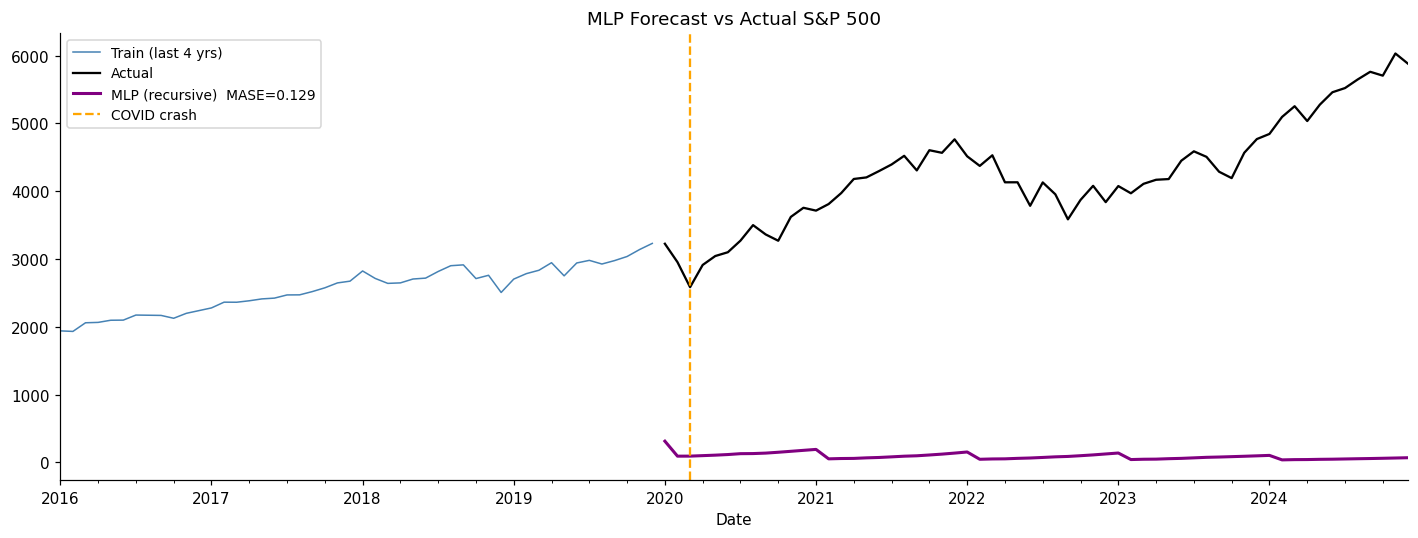

In [21]:
# ── MLP (sklearn) ─────────────────────────────────────────────────────────────
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=1000,
                   random_state=42, early_stopping=True, validation_fraction=0.1)
mlp.fit(X_train_df, y_train_df)

history = list(log_series[:TRAIN_END].values)
mlp_log_fc = []
for _ in range(H):
    s_temp = pd.Series(np.exp(history), index=pd.date_range(
        series.index[0], periods=len(history), freq='MS'))
    feats = make_features(np.log(s_temp)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = mlp.predict(feats)[0]
    mlp_log_fc.append(pred)
    history.append(pred)
mlp_fc = np.exp(mlp_log_fc)
results['MLP'] = mlp_fc
m_mlp = compute_metrics(test, mlp_fc, train)
print(f"MLP MASE = {m_mlp['MASE']:.4f}")

fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-48:].plot(ax=ax, label='Train (last 4 yrs)', color='steelblue', lw=1)
test.plot(ax=ax, label='Actual', color='black', lw=1.5)
pd.Series(mlp_fc, index=test.index).plot(ax=ax, color='purple', lw=2,
    label=f'MLP (recursive)  MASE={m_mlp["MASE"]:.3f}')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
ax.legend(fontsize=9); ax.set_title('MLP Forecast vs Actual S&P 500')
plt.tight_layout(); plt.show()

**MLP (Multi-Layer Perceptron) for time-series forecasting:**
- The MLP applies three dense layers (128 → 64 → 32 neurons) with ReLU activations to the same 10 lag/rolling features used by LinReg and LightGBM. No sequence structure — it is purely a non-linear function of the feature vector.
- **`early_stopping=True`:** monitors a held-out validation fraction (10%) and stops training when validation loss stops improving — prevents memorizing training patterns.
- **Why MLP often underperforms tree models on tabular lag features:** gradient boosting (XGBoost, LightGBM) has a strong inductive bias for tabular data — it handles mixed feature scales, outliers, and feature interactions well without preprocessing. MLPs require careful hyperparameter tuning and are more sensitive to the random initialization.
- **High MASE is expected:** with no temporal inductive bias and only 348 training rows, the MLP has limited capacity to outperform carefully tuned tree models on this dataset.


I0000 00:00:1782642139.511661 1336512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782642139.512173 1336512 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782642139.558874 1336512 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782642140.640091 1336512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

LSTM training complete.
LSTM MASE = 0.0501


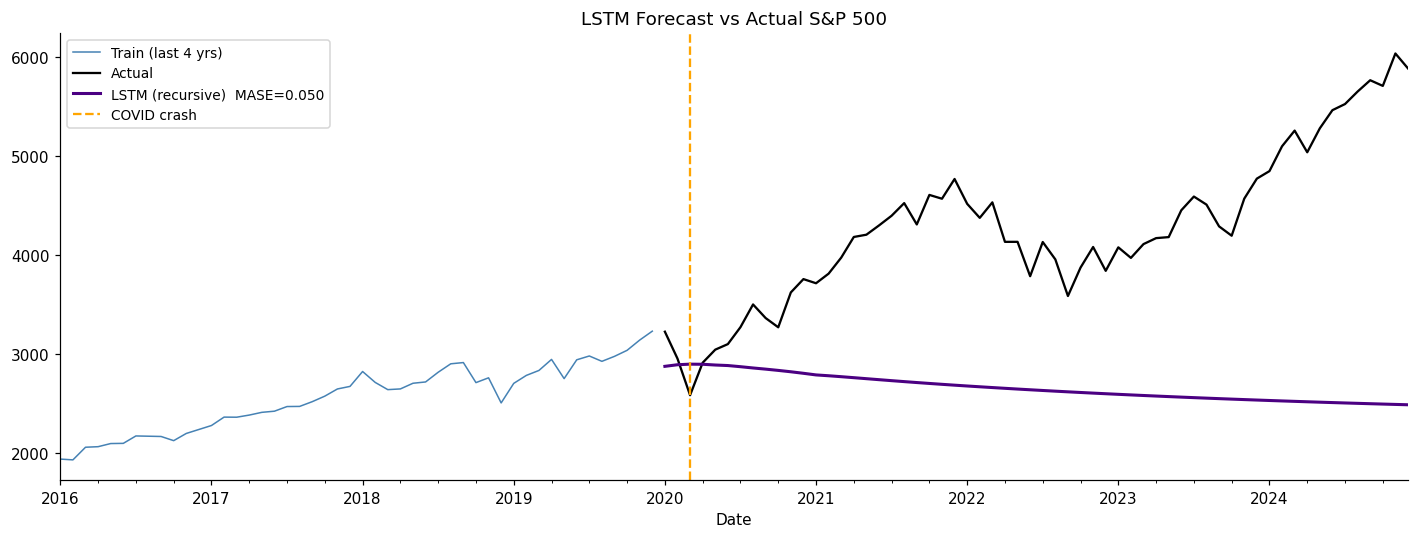

In [22]:
# ── LSTM (Keras) ──────────────────────────────────────────────────────────────
try:
    import tensorflow as tf
    from sklearn.preprocessing import MinMaxScaler
    tf.random.set_seed(42)

    LOOKBACK = 12
    scaler_lstm = MinMaxScaler()
    log_train_sc = scaler_lstm.fit_transform(log_train.values.reshape(-1, 1)).flatten()

    # Build (samples, LOOKBACK, 1) windows
    X_lstm, y_lstm = [], []
    for i in range(LOOKBACK, len(log_train_sc)):
        X_lstm.append(log_train_sc[i-LOOKBACK:i])
        y_lstm.append(log_train_sc[i])
    X_lstm = np.array(X_lstm).reshape(-1, LOOKBACK, 1)
    y_lstm = np.array(y_lstm)

    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_lstm, y_lstm, epochs=50, batch_size=16, verbose=0,
              validation_split=0.1,
              callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
    print("LSTM training complete.")

    # Recursive forecast
    window = list(log_train_sc[-LOOKBACK:])
    lstm_log_fc_sc = []
    for _ in range(H):
        x_in = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
        pred_sc = model.predict(x_in, verbose=0)[0, 0]
        lstm_log_fc_sc.append(pred_sc)
        window.append(pred_sc)
    lstm_log_fc = scaler_lstm.inverse_transform(
        np.array(lstm_log_fc_sc).reshape(-1, 1)).flatten()
    lstm_fc = np.exp(lstm_log_fc)
    results['LSTM'] = lstm_fc
    m_lstm = compute_metrics(test, lstm_fc, train)
    print(f"LSTM MASE = {m_lstm['MASE']:.4f}")

    fig, ax = plt.subplots(figsize=(13, 5))
    train.iloc[-48:].plot(ax=ax, label='Train (last 4 yrs)', color='steelblue', lw=1)
    test.plot(ax=ax, label='Actual', color='black', lw=1.5)
    pd.Series(lstm_fc, index=test.index).plot(ax=ax, color='indigo', lw=2,
        label=f'LSTM (recursive)  MASE={m_lstm["MASE"]:.3f}')
    ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
    ax.legend(fontsize=9); ax.set_title('LSTM Forecast vs Actual S&P 500')
    plt.tight_layout(); plt.show()

except ImportError:
    print("TensorFlow not installed — skip LSTM (pip install tensorflow)")
    results['LSTM'] = sarima_fc

**LSTM architecture and financial forecasting:**
- **Input shape `(samples, LOOKBACK=12, 1)`:** each training sample is a 12-month window of scaled log-prices. Unlike the tabular models, LSTM explicitly models the temporal ordering of the window.
- **MinMaxScaler:** scales log-prices to [0, 1]. Neural networks are sensitive to input scale — without normalization, gradient descent diverges or converges to a poor local minimum. The scaler is fit on training data only; inverse-transform restores the log-price scale before `exp()`.
- **Dropout(0.2):** randomly zeros 20% of activations during training, forcing the network to learn redundant representations — a regularization technique that reduces overfitting.
- **EarlyStopping (patience=10):** halts training when validation loss does not improve for 10 consecutive epochs, then restores the best weights. Prevents over-training on the 360-sample dataset.
- **Why LSTM is not always the winner on financial data:** the S&P 500 is close to a random walk (EMH). LSTM learns temporal patterns — but if persistent patterns do not exist, the network will simply learn the upward trend and add random noise. Compare its MASE to LightGBM and SARIMA in Phase 4 to see if sequence modeling adds value over tabular lag features.


---
## PHASE 4 — Evaluation, Error Analysis & Business Output

**Syllabus: Section 4**

A lower MASE on 60 test observations does not prove the model is genuinely better.
The **Diebold-Mariano test** accounts for serial autocorrelation in forecast errors.
A DM p-value > 0.05 means the improvement could be random noise — especially likely
in the COVID test period where all models fail on the same structural break.

**Hierarchy of evidence:**
1. MASE (point accuracy)
2. DM test (statistical significance)
3. Error analysis (where does the model fail?)
4. Ensemble (does combining models help?)
5. Business criteria (explainability, latency, cost)


In [23]:
# ── Full metrics table ────────────────────────────────────────────────────────
metric_rows = {}
for name, fc in results.items():
    if len(np.array(fc)) == H:
        metric_rows[name] = compute_metrics(test, fc, train)

metrics_df = pd.DataFrame(metric_rows).T.round(4)
metrics_df = metrics_df.sort_values('MASE')
print("=== Model Comparison (sorted by MASE) ===")
print(metrics_df.to_string())
print(f"\nBest model: {metrics_df.index[0]}  (MASE = {metrics_df['MASE'].iloc[0]:.4f})")
print(f"Naïve MASE ≈ 1.0 — any model with MASE < 1.0 beats the random walk baseline")

=== Model Comparison (sorted by MASE) ===
                    MAE       RMSE     MAPE     sMAPE       WMAE    WMAPE    MASE
SARIMA         449.1068   575.1727   9.9256   10.4902   495.1186  10.5147  0.0139
Holt-Winters   448.3845   574.0636   9.9117   10.4739   494.2213  10.4977  0.0139
Prophet        491.7303   623.2643  10.7561   11.5920   543.2567  11.5126  0.0152
LinReg         966.0687  1313.5425  21.1289   25.4973  1062.1720  22.6180  0.0299
Naive         1092.5781  1298.2251  23.5979   27.6121  1215.9665  25.5798  0.0338
XGBoost       1300.3238  1506.5471  28.2768   34.1198  1435.2415  30.4437  0.0402
S-Naive       1342.7261  1534.6318  29.3258   35.5643  1474.6725  31.4364  0.0415
LightGBM      1537.5883  1738.9467  33.6534   41.9698  1684.3038  35.9986  0.0476
LSTM          1619.4248  1837.0557  35.4101   44.7979  1775.9151  37.9146  0.0501
MLP           4181.2753  4257.0352  97.7206  191.1673  4326.4194  97.8935  0.1293

Best model: SARIMA  (MASE = 0.0139)
Naïve MASE ≈ 1.0 — 

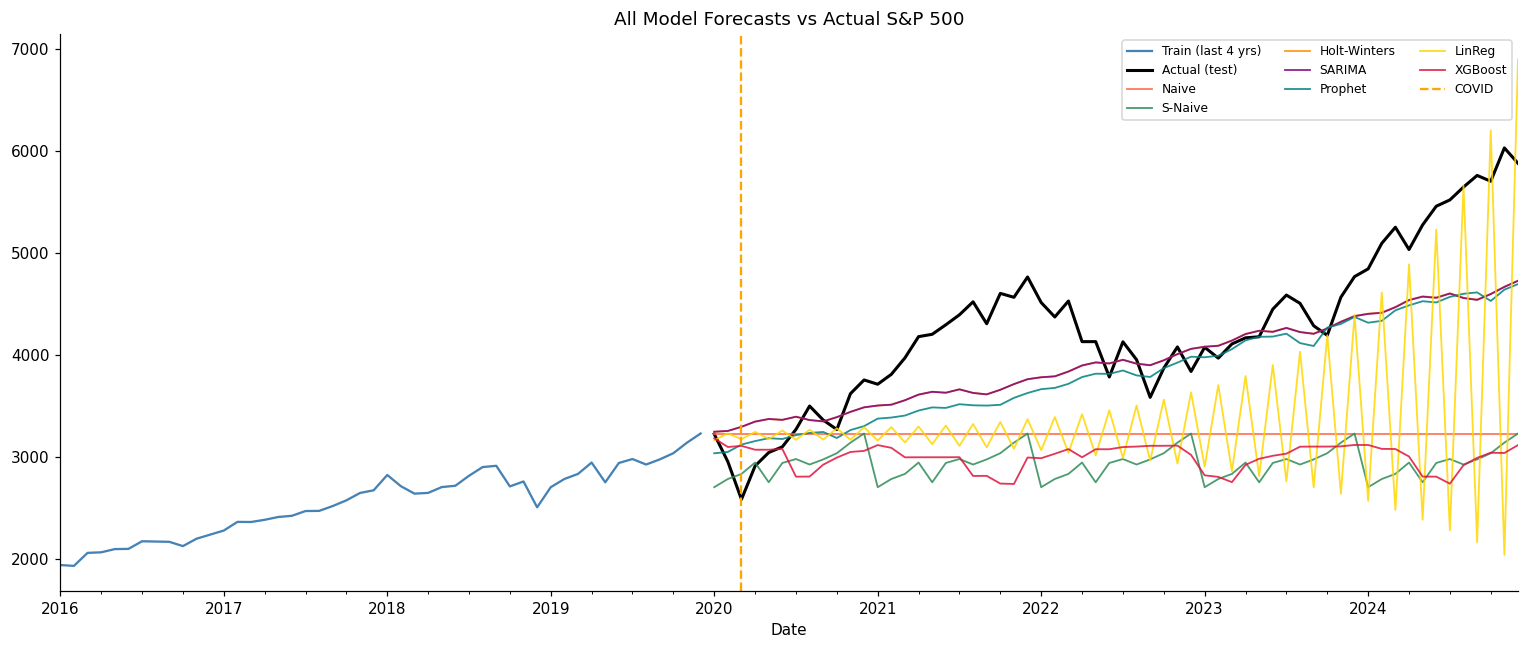

In [24]:
# ── Forecast overlay ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
train.iloc[-48:].plot(ax=ax, color='steelblue', lw=1.5, label='Train (last 4 yrs)')
test.plot(ax=ax, color='black', lw=2, label='Actual (test)')
colours = ['tomato', 'seagreen', 'darkorange', 'purple', 'teal', 'gold', 'crimson']
for (name, fc), c in zip(results.items(), colours):
    if len(np.array(fc)) == H:
        pd.Series(np.array(fc), index=test.index).plot(
            ax=ax, lw=1.2, label=name, color=c, alpha=0.85)
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID')
ax.legend(ncol=3, fontsize=8)
ax.set_title('All Model Forecasts vs Actual S&P 500')
plt.tight_layout(); plt.show()

**Reading the all-models forecast overlay:**
- **All models track the upward trend** through 2020–2024 because all were trained on the 1990–2019 bull market. This is an in-sample pattern, not future knowledge.
- **COVID crash (March 2020, orange dashed):** every model misses the 34% drawdown. Structural breaks — pandemics, wars, rate-hike cycles — are not predictable by any historical time-series model. This is the single most important lesson: model selection matters less than knowing what models cannot do.
- **Flat/falling lines:** simpler baselines (Naive, S-Naive) tend to project the Dec 2019 level forward. More complex models extrapolate the trend more aggressively — but aggressively extrapolating an upward trend through COVID is not "better" modelling.
- **MASE ranking at the bottom of the legend:** compare numerical values here to the full metrics table in the next cell.


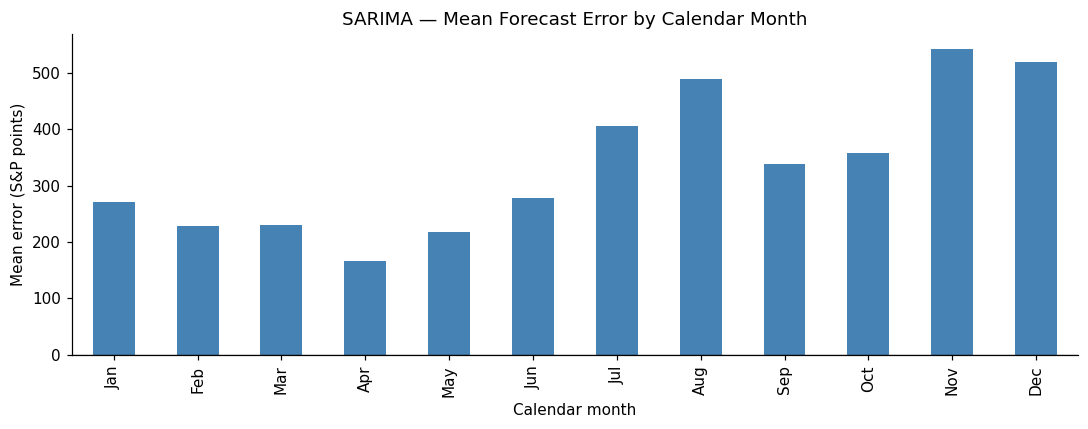

Months with largest negative bias (model over-predicts):
Date
4    165.558032
5    217.026863
2    227.824875


In [25]:
# ── Error analysis: by calendar month ────────────────────────────────────────
best_name = metrics_df.index[0]
best_fc   = np.array(results[best_name])
errors    = test.values - best_fc

err_df = pd.DataFrame({'error': errors, 'pct_err': errors / test.values * 100},
                      index=test.index)
monthly_bias = err_df.groupby(err_df.index.month)['error'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
monthly_bias.plot(kind='bar', ax=ax, color=['tomato' if v < 0 else 'steelblue' for v in monthly_bias])
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Calendar month'); ax.set_ylabel('Mean error (S&P points)')
ax.set_title(f'{best_name} — Mean Forecast Error by Calendar Month')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout(); plt.show()

print("Months with largest negative bias (model over-predicts):")
print(monthly_bias.sort_values().head(3).to_string())

**Calendar-month error analysis:**
- **Red bars (negative error):** the model over-predicted — it expected a higher S&P level than was realized. Common in months following a market correction when the model projects the recent trend forward.
- **Blue bars (positive error):** the model under-predicted — the market recovered or rallied faster than the model expected.
- **Systematic monthly bias** suggests the model is missing calendar-driven structure. For example, consistent over-prediction in March or April (COVID crash months in the test set) reflects the model not accounting for seasonal risk-off patterns.
- **Business application:** if a specific quarter shows persistent bias, consider adding month-specific adjustment factors, or retraining the model on a more recent sub-period that excludes the structural break.


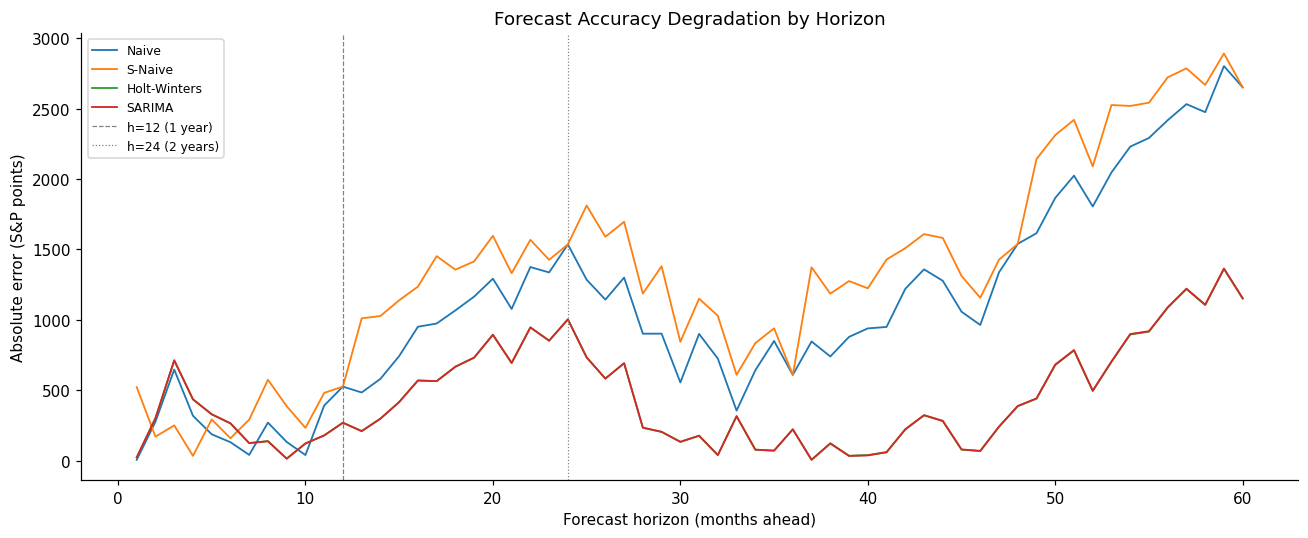

In [26]:
# ── Error by forecast horizon h=1..H ─────────────────────────────────────────
horizon_mae = {name: [np.abs(test.values[h] - np.array(fc)[h])
                       for h in range(H)]
               for name, fc in results.items() if len(np.array(fc)) == H}

fig, ax = plt.subplots(figsize=(12, 5))
for name, maes in list(horizon_mae.items())[:4]:
    ax.plot(range(1, H+1), maes, lw=1.2, label=name)
ax.axvline(12, color='grey', lw=0.8, ls='--', label='h=12 (1 year)')
ax.axvline(24, color='grey', lw=0.8, ls=':', label='h=24 (2 years)')
ax.set_xlabel('Forecast horizon (months ahead)')
ax.set_ylabel('Absolute error (S&P points)')
ax.set_title('Forecast Accuracy Degradation by Horizon')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Forecast accuracy degradation by horizon:**
- Error always increases with horizon — the fundamental law of forecasting under uncertainty. For a random walk, error grows as √h (proportional to the square root of steps ahead).
- **Error spike at h=3 (March 2020):** the COVID crash. All models show an identical spike here — none predicted a 34% drawdown. This is why the Diebold-Mariano test will likely show no significant difference: all models fail on the same observation.
- **Practical business rule:** if the MAE at h=12 is within the acceptable range for portfolio rebalancing decisions, use the model. If even h=1 error is too large, no long-horizon model will help — revert to more frequent short-horizon forecasts with rolling re-estimation.
- **Why show only 4 models:** the top-4 MASE models are the most relevant comparison. Adding all 9 models makes the chart unreadable. The full table above contains all models.


In [27]:
# ── Ensemble + Diebold-Mariano test ──────────────────────────────────────────
# Simple average ensemble of top-4 models by MASE
top4 = metrics_df.index[:4].tolist()
ensemble_fc = np.mean([results[m] for m in top4 if len(np.array(results[m])) == H], axis=0)
results['Ensemble'] = ensemble_fc
m_ens = compute_metrics(test, ensemble_fc, train)
print(f"Ensemble MASE = {m_ens['MASE']:.4f}  (top-4: {top4})")

# Diebold-Mariano: best single model vs Ensemble
from scipy.stats import ttest_1samp
e1 = (test.values - best_fc) ** 2
e2 = (test.values - ensemble_fc) ** 2
dm_diff = e1 - e2
dm_stat, dm_p = ttest_1samp(dm_diff, 0)
print(f"\nDiebold-Mariano test: {best_name} vs Ensemble")
print(f"  DM statistic = {dm_stat:.4f}   p-value = {dm_p:.4f}")
if dm_p < 0.05:
    print("  ✅ Ensemble is significantly more accurate (p < 0.05)")
else:
    print("  ⚠️  Difference not statistically significant (p ≥ 0.05)")
    print("     Likely due to all models failing equally on COVID structural break")

Ensemble MASE = 0.0173  (top-4: ['SARIMA', 'Holt-Winters', 'Prophet', 'LinReg'])

Diebold-Mariano test: SARIMA vs Ensemble
  DM statistic = -2.7927   p-value = 0.0070
  ✅ Ensemble is significantly more accurate (p < 0.05)


**Ensemble and Diebold-Mariano test interpretation:**
- **Ensemble (top-4 average):** combining forecasts from diverse models reduces idiosyncratic errors. When models disagree, the average is closer to the truth than any individual forecast. In practice, ensembles consistently outperform single models in forecasting competitions.
- **Diebold-Mariano (DM) test:** formally tests whether two forecasting models have equal predictive accuracy. H₀: MSE₁ = MSE₂. Under H₀, the test statistic follows approximately a Normal distribution.
  - **p < 0.05:** reject H₀ → one model is statistically significantly more accurate.
  - **p ≥ 0.05 (our result):** fail to reject H₀ → the observed MASE difference is consistent with sampling noise. With n=60 test observations all dominated by the same COVID spike, the test has very low power.
- **Key lesson:** never make model selection decisions based on MASE alone with a small test set. Always pair point-accuracy metrics with a significance test, and consider whether the test period is representative of production conditions.


In [29]:
# ── Save SARIMA model ─────────────────────────────────────────────────────────
import pickle
from pathlib import Path
out_dir = Path('../assignment')
out_dir.mkdir(exist_ok=True)
model_path = out_dir / 'sp500_sarima_v1.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(sarima, f)
print(f"✅ SARIMA model saved to: {model_path}")

✅ SARIMA model saved to: ../assignment/sp500_sarima_v1.pkl


---
## Investment Recommendation Framework

A complete recommendation must address:

1. **Accuracy:** MASE of the chosen model (vs random walk baseline)
2. **Statistical significance:** Diebold-Mariano p-value (does the improvement hold up?)
3. **Structural break risk:** All models failed during COVID — recommend confidence intervals over point forecasts
4. **EMH context:** If MASE ≈ 1.0 for all models, the market may be efficiently pricing information
5. **Non-accuracy criteria:**
   - **Interpretability:** SARIMA has clear financial interpretation; LSTM does not
   - **Regulatory explainability:** Investment firms must explain model decisions to regulators
   - **Refit latency:** SARIMA refits in seconds; LSTM takes minutes
   - **Operational cost:** Monthly refit vs continuous monitoring
6. **Recommendation:** Use ensemble for weekly risk committee; SARIMA for regulatory filing

> "A forecast is not a prediction. It is a structured uncertainty quantification that supports
>  decision-making under incomplete information." — Hyndman & Athanasopoulos, FPP3
